In [ ]:
from google.colab import drive
# Mount your Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics
!apt-get install fonts-dejavu -y
!pip install scikit-image scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.8 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-dejavu-core fonts-dejavu-extra
The following NEW packages will be installed:
  fonts-dejavu fonts-dejavu-core fonts-dejavu-extra
0 upgraded, 3 newly installed, 0 to remove and 2 not upgraded.
Need to get 3,085 kB of archives.
After this operation, 10.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-core all 2.37-2build1 [1,041 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-extra all 2.37-2build1 [2,041 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-dejavu all 2.37-2build1 [3,192 B]
Fetched 3,085 kB in 2s (2,017 kB/s)
Selecting previously unselected package fonts-dejavu-core.
(Reading database ... 118194 files and directories currently installed

In [ ]:
# ================================
#  Setup, Imports & Model Loading
# ================================
import cv2
import numpy as np
import tensorflow as tf
from ultralytics import YOLO
import time
import re
from google.colab.patches import cv2_imshow
from google.colab import files
import math
from sklearn.cluster import DBSCAN
from skimage.morphology import skeletonize, remove_small_objects, binary_erosion
from PIL import Image, ImageDraw, ImageFont
from skimage import measure

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# -------------------------------
# Define model paths and load models
# -------------------------------
component_model_path = "/content/drive/My Drive/Thesis related/Main_pipeline/YOLO_element_best.pt"  # YOLO model for components
text_model_path      = "/content/drive/My Drive/Thesis related/Main_pipeline/YOLO_text_best.pt"     # YOLO model for text regions
crnn_model_path      = "/content/drive/My Drive/Thesis related/Main_pipeline/crnn_inference_model.h5"  # CRNN model

component_model = YOLO(component_model_path)
text_model      = YOLO(text_model_path)
crnn_model      = tf.keras.models.load_model(crnn_model_path, compile=False)

# Character set used during CRNN training (must match training configuration)
CHARSET = "0123456789abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZΩµ-.∠"

In [ ]:
# =============================================================================
# Pipeline 1: Component & Text Detection (Elements & OCR)
# =============================================================================

def decode_prediction(pred):
    """
    Decode the prediction output from CRNN.
    """
    pred = np.squeeze(pred)
    best_indices = list(np.argmax(pred, axis=1))
    decoded, prev = "", -1
    for idx in best_indices:
        if idx != prev and idx < len(CHARSET):
            decoded += CHARSET[idx]
        prev = idx
    return decoded

def preprocess_for_crnn(image, img_size=(128, 32)):
    """
    Preprocess an image for CRNN inference.
    """
    image = cv2.fastNlMeansDenoising(image, None, h=5, templateWindowSize=7, searchWindowSize=21)
    image = cv2.resize(image, img_size)
    image = image / 255.0
    image = np.expand_dims(image, axis=-1)  # add channel dimension (grayscale)
    image = np.expand_dims(image, axis=0)     # add batch dimension
    return image

def load_image():
    """
    Upload an image and crop ~5% from each side.
    This cropped image will be used for all subsequent processing.
    """
    uploaded = files.upload()
    image_path = list(uploaded.keys())[0]
    image = cv2.imread(image_path)
    h, w = image.shape[:2]
    crop_p = 0.02  # 5% crop
    x_start = int(w * crop_p)
    y_start = int(h * crop_p)
    x_end   = int(w * (1 - crop_p))
    y_end   = int(h * (1 - crop_p))
    cropped = image[y_start:y_end, x_start:x_end]
    return cropped, image_path
def apply_nms(boxes, confidences, iou_threshold=0.5):
    """
    Apply Non-Maximum Suppression (NMS) to avoid overlapping bounding boxes.
    Returns indices of the boxes to keep.
    """
    rects = [ [x1, y1, x2 - x1, y2 - y1] for x1, y1, x2, y2, _, _ in boxes ]  # Convert to x, y, w, h
    scores = [conf for _, _, _, _, conf, _ in boxes]
    indices = cv2.dnn.NMSBoxes(rects, scores, score_threshold=0.3, nms_threshold=iou_threshold)

    # Check if indices is not None and reshape it to a 2D array if necessary
    if indices is not None and len(indices) > 0:
        # Reshape indices to ensure it's a 2D array of shape (N, 1) or similar
        # This handles cases where NMSBoxes might return a flat array of scalars
        indices = indices.reshape(-1, 1)
        # Now iterate through the reshaped indices
        return [i[0] for i in indices]
    else:
        return []


def detect_components(image):
    """
    Detect components using the YOLO component model.
    Applies NMS to avoid duplicate detections.
    Returns a list of tuples: (x1, y1, x2, y2, confidence, class_id)
    """
    image_resized = cv2.resize(image, (640, 640))
    results = component_model(image_resized)
    boxes   = results[0].boxes.xywh.cpu().numpy()
    confs   = results[0].boxes.conf.cpu().numpy()
    cls_ids = results[0].boxes.cls.cpu().numpy().astype(int)
    orig_h, orig_w = image.shape[:2]
    raw_boxes = []

    for i, box in enumerate(boxes):
        x_center, y_center, w_box, h_box = box
        x1 = int((x_center - w_box/2) * orig_w / 640)
        y1 = int((y_center - h_box/2) * orig_h / 640)
        x2 = int((x_center + w_box/2) * orig_w / 640)
        y2 = int((y_center + h_box/2) * orig_h / 640)
        raw_boxes.append((x1, y1, x2, y2, confs[i], cls_ids[i]))

    # Apply Non-Maximum Suppression
    keep_indices = apply_nms(raw_boxes, [b[4] for b in raw_boxes])
    component_boxes = [raw_boxes[i] for i in keep_indices]
    return component_boxes





def detect_text_regions(image):
    """
    Detect text regions using the YOLO text model.
    Returns a list of tuples: (x1, y1, x2, y2, confidence)
    """
    image_resized = cv2.resize(image, (640, 640))
    results = text_model(image_resized)
    boxes   = results[0].boxes.xywh.cpu().numpy()
    confs   = results[0].boxes.conf.cpu().numpy()
    orig_h, orig_w = image.shape[:2]
    text_boxes = []
    for i, box in enumerate(boxes):
        x_center, y_center, w_box, h_box = box
        x1 = int((x_center - w_box/2) * orig_w / 640)
        y1 = int((y_center - h_box/2) * orig_h / 640)
        x2 = int((x_center + w_box/2) * orig_w / 640)
        y2 = int((y_center + h_box/2) * orig_h / 640)
        text_boxes.append((x1, y1, x2, y2, confs[i]))
    return text_boxes

def crop_region(image, box):
    """
    Crop a region based on the bounding box.
    """
    x1, y1, x2, y2 = box[:4]
    return image[y1:y2, x1:x2]

def assign_text_to_components(component_boxes, text_boxes, image):
    """
    For each detected text region, run OCR and assign the recognized text
    to the nearest component (using box centers).
    Returns a list of tuples: (component_box, assigned_text, distance)
    """
    text_data = []
    for tb in text_boxes:
        x1, y1, x2, y2, conf = tb
        cropped = crop_region(image, tb)
        if len(cropped.shape) == 3:
            cropped_gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
        else:
            cropped_gray = cropped
        ocr_img = preprocess_for_crnn(cropped_gray)
        preds = crnn_model.predict(ocr_img)
        text = decode_prediction(preds[0])
        m = re.search(r"[\d\.Ωµ∠]+", text)
        value = m.group() if m else None
        center = ((x1+x2)//2, (y1+y2)//2)
        text_data.append({"box": (x1, y1, x2, y2), "center": center, "text": text, "value": value})

    component_assignments = []
    for comp in component_boxes:
        cx1, cy1, cx2, cy2, conf, cls = comp
        comp_center = ((cx1+cx2)//2, (cy1+cy2)//2)
        min_dist = float('inf')
        assigned_text = None
        for td in text_data:
            if td["value"] is not None:
                dist = np.sqrt((comp_center[0]-td["center"][0])**2 + (comp_center[1]-td["center"][1])**2)
                if dist < min_dist:
                    min_dist = dist
                    assigned_text = td["text"]
        component_assignments.append((comp, assigned_text, min_dist))
    return component_assignments, text_data

In [ ]:
def resize_for_export(img, min_side=900, max_side=3000):
    h, w = img.shape[:2]

    # Scale up so the smaller side becomes at least min_side
    scale_up = min_side / min(h, w)

    # Scale down so the larger side becomes at most max_side
    scale_down = max_side / max(h, w)

    # Choose a valid scale
    if min(h, w) < min_side:
        scale = scale_up
    elif max(h, w) > max_side:
        scale = scale_down
    else:
        scale = 1.0

    # Safety check: after scaling, don't let max side exceed max_side
    if max(h * scale, w * scale) > max_side:
        scale = scale_down

    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    # Final clamp just in case
    new_w = max(1, min(new_w, max_side))
    new_h = max(1, min(new_h, max_side))

    interp = cv2.INTER_CUBIC if scale > 1 else cv2.INTER_AREA
    return cv2.resize(img, (new_w, new_h), interpolation=interp)

In [ ]:
def apply_wire_cleanup(image):
    """
    Keeps only the largest connected wire-like structure and returns
    a clean white-background image with only main wires in black.
    """
    original_height, original_width = image.shape[:2]

    blurred = cv2.GaussianBlur(image, (9, 9), 0)
    gray = cv2.cvtColor(blurred, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    labels = measure.label(thresh, connectivity=2)
    properties = measure.regionprops(labels)

    area_threshold = max([prop.area for prop in properties]) if properties else 0

    mask = np.zeros_like(thresh)
    for prop in properties:
        if prop.area >= area_threshold:
            coords = prop.coords
            mask[coords[:, 0], coords[:, 1]] = 255

    # Create white background, place black wires where mask is white
    clean_output = np.ones((original_height, original_width, 3), dtype=np.uint8) * 255
    clean_output[mask == 255] = [0, 0, 0]

    return clean_output


Saving circuit83.jpg to circuit83 (2).jpg

0: 640x640 1 DC Voltage Source, 2 Resistors, 1 Inductor, 1 Capacitor, 195.5ms
Speed: 3.3ms preprocess, 195.5ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 5 texts, 214.2ms
Speed: 5.4ms preprocess, 214.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Detected Component List:
Component 1: (524, 84, 637, 148, np.float32(0.8646528), np.int64(4))
Component 2: (661, 226, 741, 299, np.float32(0.802496), np.int64(1))
Component 3: (399, 225, 471, 304, np.float32(0.65433025), np.int64(1))
Component 4: (281, 93, 413, 138, np.float32(0.5432954), np.int64(3))
Component 5: (36, 237, 149, 346, np.float32(0.41382664), np.int64(0))

Detected Text List:
Text Region 1: (577, 31, 747, 85, np.float32(0.8213979))
Text Region 2: (716, 289, 830, 346, np.float32(0.8034281))
Text Region 3: (119, 317, 264, 373, np.float32(0.7899461))
Text Region 4: (456, 284, 563, 338, np.float32(0.77879786))
Text Region 5: (274, 21, 

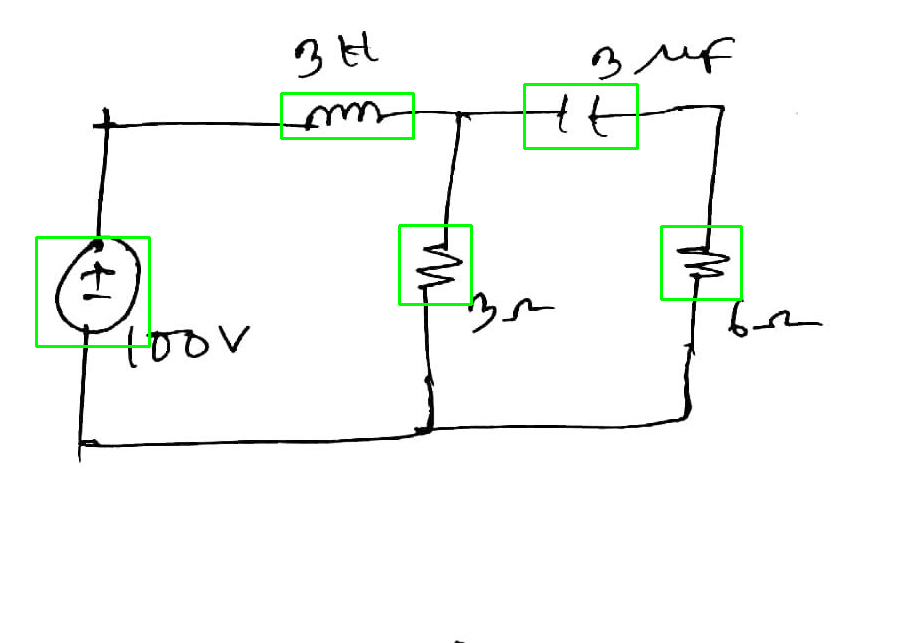


Displayed Image: Only Element (Component) Detection.


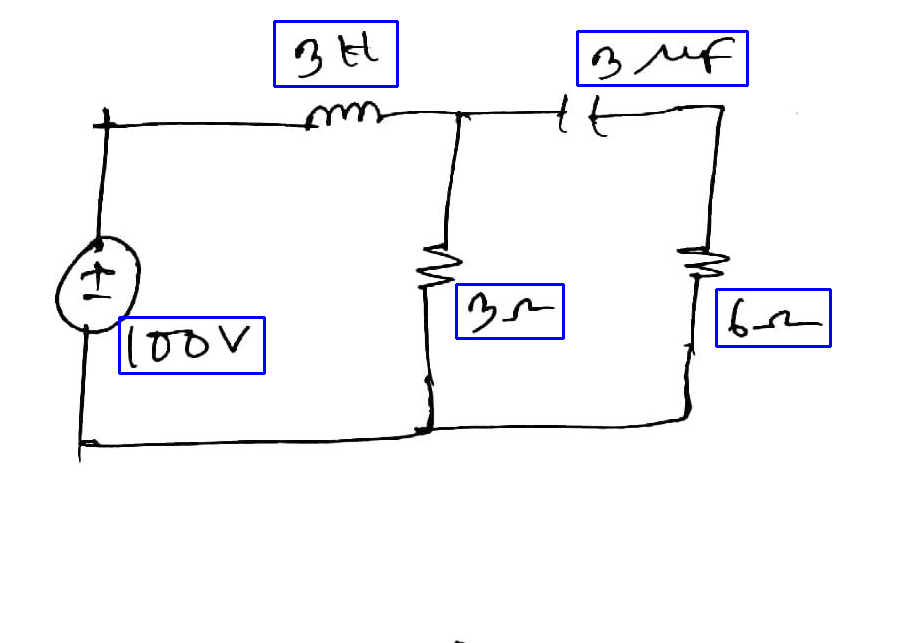

Displayed Image: Only Text Detection.


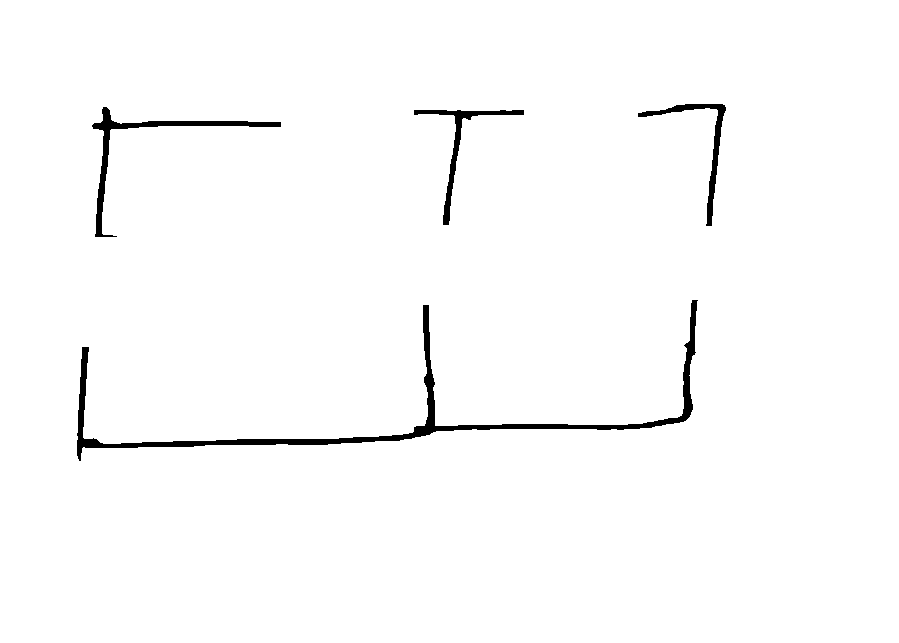


Detected Wire Endpoints:
Wire 0 Endpoint W0_0: (696, 299)
Wire 0 Endpoint W0_1: (426, 307)
Wire 0 Endpoint W0_2: (85, 350)
Wire 0 Endpoint W0_3: (79, 459)
Wire 1 Endpoint W1_0: (415, 112)
Wire 1 Endpoint W1_1: (521, 112)
Wire 1 Endpoint W1_2: (445, 221)
Wire 2 Endpoint W2_0: (105, 111)
Wire 2 Endpoint W2_1: (278, 124)
Wire 2 Endpoint W2_2: (95, 126)
Wire 2 Endpoint W2_3: (111, 234)
Wire 3 Endpoint W3_0: (639, 115)
Wire 3 Endpoint W3_1: (707, 223)


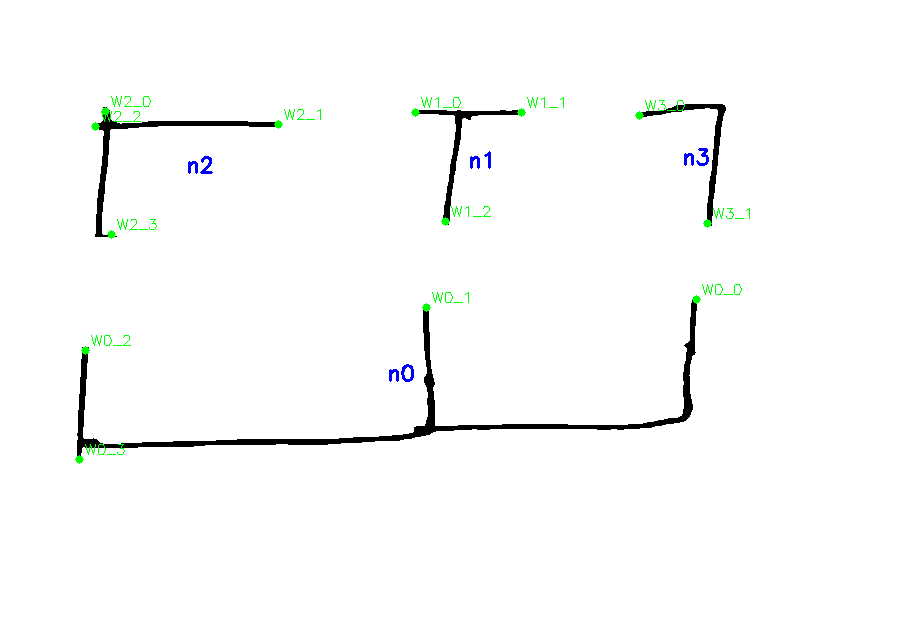

Displayed Image: Node (Wire) Detection.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step

Component-to-Text Value Mapping:
Component ID | Class       | Component Center (x,y) | Assigned Text | Text Center (x,y) | Distance (px)
-------------------------------------------------------------------------------------------------------
          1 | Capacitor  | (662 , 58  ) | 3µF          | (580 , 116 ) | 100.44
          2 | Resistor   | (773 , 317 ) | 6Ω           | (701 , 262 ) | 90.60
          3 | Resistor   | (509 , 311 ) | 3Ω           | (435 , 264 ) | 87.66
          4 | Inductor   | (335 , 53  ) | 3H           | (347 , 115 ) | 63.15
          5 | VoltageSrc | (191 , 345 ) | 100V         | (92  , 291 ) | 112.77

Component Midpoint-to-Wire Mapping:
Component | Side  | Midpoint (x,y) | Nearest Wire ID | Distance
-----------------------------------

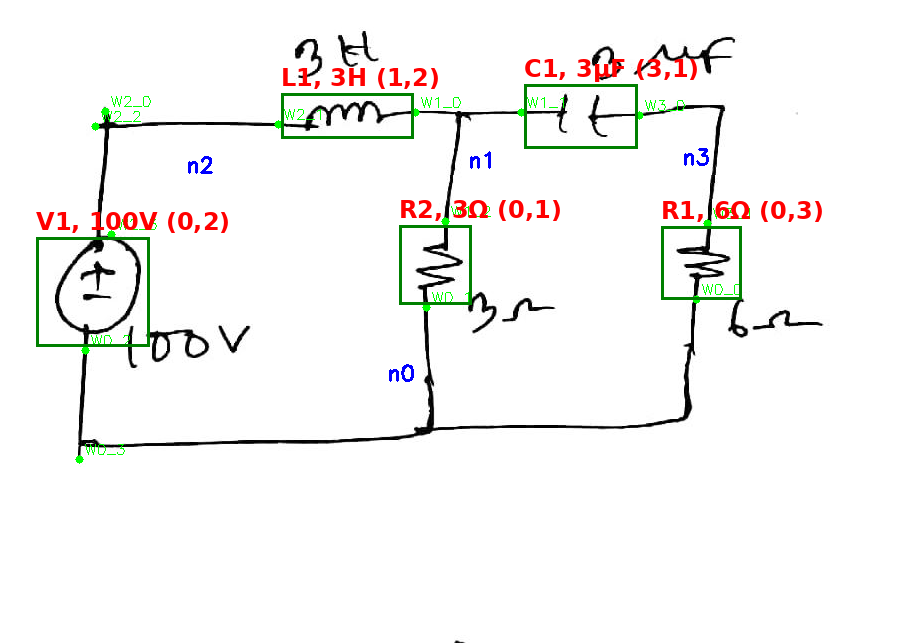

Displayed Image: Final Unified Detection (Components, OCR, & Node Mapping).

Generated Netlist:
* Generated Netlist
.ground 0  # Auto-detected wire 0
.lib nom.lib

C1 3 1 3e-06
R1 0 3 6.0
R2 0 1 3.0
L1 1 2 3.0
V1 0 2 DC 100.0

.tran 1m 1
.end


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Component Details:
C1: C between (3, 1), Value=3e-06 (Original text: 3µF)
R1: R between (0, 3), Value=6.0 (Original text: 6Ω)
R2: R between (0, 1), Value=3.0 (Original text: 3Ω)
L1: L between (1, 2), Value=3.0 (Original text: 3H)
V1: V between (0, 2), Value=100.0 (Original text: 100V)


In [ ]:
# =============================================================================
# Pipeline 2: Wire (Node) Detection & Component-to-Wire Mapping
# =============================================================================

def detect_boxes(image, model):
    """
    Detect boxes using a given YOLO model.
    Returns a list of boxes in (x1, y1, x2, y2) format.
    """
    image_resized = cv2.resize(image, (640, 640))
    results = model(image_resized)
    boxes   = results[0].boxes.xywh.cpu().numpy()
    orig_h, orig_w = image.shape[:2]
    processed_boxes = []
    for box in boxes:
        x_center, y_center, w_box, h_box = box
        x1 = int((x_center - w_box/2) * orig_w / 640)
        y1 = int((y_center - h_box/2) * orig_h / 640)
        x2 = int((x_center + w_box/2) * orig_w / 640)
        y2 = int((y_center + h_box/2) * orig_h / 640)
        processed_boxes.append((x1, y1, x2, y2))
    return processed_boxes

def remove_detected_regions(image, regions, fill_color=(255,255,255)):
    """
    Mask out the given rectangular regions from the image.
    """
    for region in regions:
        x1, y1, x2, y2 = region
        cv2.rectangle(image, (x1,y1), (x2,y2), fill_color, -1)
    return image

def isolate_wires(image):
    """
    Isolate wires via Canny edge detection and dilation.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    kernel = np.ones((3,3), np.uint8)
    edges_dilated = cv2.dilate(edges, kernel, iterations=1)
    return edges_dilated

def find_endpoints_iterative(skel):
    """
    Iteratively find endpoints from a skeleton and merge closely located points.
    """
    endpoints = []
    junctions = []
    h, w = skel.shape
    for i in range(h):
        for j in range(w):
            if skel[i,j]:
                count = 0
                for di in (-1, 0, 1):
                    for dj in (-1, 0, 1):
                        if di==0 and dj==0:
                            continue
                        ni, nj = i+di, j+dj
                        if 0<=ni<h and 0<=nj<w and skel[ni,nj]:
                            count += 1
                if count == 1:
                    endpoints.append((j,i))  # (x, y)
                elif count >= 3:
                    junctions.append((j,i))
    filtered = []
    thresh = 5
    for ep in endpoints:
        if all(math.hypot(ep[0]-jp[0],ep[1]-jp[1])>=thresh for jp in junctions):
            filtered.append(ep)
    if filtered:
        filtered = np.array(filtered, dtype=np.float32)
        clustering = DBSCAN(eps=8, min_samples=1).fit(filtered)
        labels = clustering.labels_
        final_points = []
        for label in set(labels):
            pts = filtered[labels==label]
            rep = np.mean(pts, axis=0)
            final_points.append((int(round(rep[0])), int(round(rep[1]))))
        return final_points
    else:
        return []

def morphologically_filter(skel):
    """
    Remove small artifacts via binary erosion and small object removal.
    """
    # Change 'structure' to 'footprint'
    eroded = binary_erosion(skel, footprint=np.ones((3,3)))
    filtered = remove_small_objects(eroded, min_size=50)
    return filtered

def detect_and_label_wires(wires_img, base_image, area_threshold=100):
    """
    Detect wires (nodes) in the wires image by finding contours.
    Annotates (draws) both wire endpoints and wire numbers.
    Returns the annotated image and a list of wire info.
    """
    contours, _ = cv2.findContours(wires_img.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    annotated_img = base_image.copy()
    wire_info = []
    wire_id = 0
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > area_threshold:
            approx = cv2.approxPolyDP(cnt, epsilon=2, closed=True)
            x, y, w, h = cv2.boundingRect(approx)
            current_wire = {'id': wire_id, 'bounding_box': (x, y, x+w, y+h), 'area': area, 'endpoints': []}
            wire_mask = np.zeros(wires_img.shape, dtype=np.uint8)
            cv2.drawContours(wire_mask, [cnt], -1, 255, thickness=cv2.FILLED)
            wire_mask_bool = wire_mask > 0
            filtered_skel = morphologically_filter(wire_mask_bool)
            skel = skeletonize(filtered_skel)
            endpoints = find_endpoints_iterative(skel)
            endpoints_info = []
            for i_ep, (ex, ey) in enumerate(endpoints):
                cv2.circle(annotated_img, (ex, ey), 4, (0,255,0), -1)
                label = f"W{wire_id}_{i_ep}"
                cv2.putText(annotated_img, label, (ex+5, ey-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
                endpoints_info.append({'label': label, 'coord': (ex, ey)})
            current_wire['endpoints'] = endpoints_info
            cx = x + w//2
            cy = y + h//2
            cv2.putText(annotated_img, f"n{wire_id}", (cx, cy),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 2)
            wire_info.append(current_wire)
            wire_id += 1
    return annotated_img, wire_info
def find_ground_wire(wire_info):
    """Identify the bottom-most wire based on bounding box position"""
    if not wire_info:
        return None
    ground_wire = max(wire_info, key=lambda w: w['bounding_box'][3])  # index 3 is y2 (bottom y)
    return ground_wire['id']
def map_components_to_wires(component_boxes, wire_info, ground_wire_id=None):
    """
    For each component (given as a 4-tuple box) compute midpoints of each side;
    then, using wire endpoints, select the two nearest wires.
    Returns a dictionary mapping: { component_id: (wire_id1, wire_id2) }.
    """
    wire_endpoints = []
    for wire in wire_info:
        for ep in wire['endpoints']:
            wire_id = wire['id']
            # Replace ground wire ID with 0 for endpoints
            if ground_wire_id is not None and wire_id == ground_wire_id:
                wire_id = 0
            wire_endpoints.append((wire_id, ep['coord']))
    mapping = {}
    # Add this print header
    print("\nComponent Midpoint-to-Wire Mapping:")
    print("Component | Side  | Midpoint (x,y) | Nearest Wire ID | Distance")
    print("---------------------------------------------------------------")

    for comp_id, box in enumerate(component_boxes, start=1):
        x1, y1, x2, y2 = box
        midpoints = {'left': (x1, (y1+y2)//2), 'top': ((x1+x2)//2, y1),
                    'right': (x2, (y1+y2)//2), 'bottom': ((x1+x2)//2, y2)}

        for side, mid in midpoints.items():
            min_dist = float('inf')
            best_wire = None
            for wire_id, coord in wire_endpoints:
                d = math.hypot(mid[0]-coord[0], mid[1]-coord[1])

                # Print details for each midpoint
                if d < min_dist:
                    min_dist = d
                    best_wire = wire_id

            # Add this print statement
            print(f"Comp {comp_id:2} | {side:6} | ({mid[0]:4}, {mid[1]:4}) | Wire {best_wire:3} | {min_dist:.2f} px")
    for comp_id, box in enumerate(component_boxes, start=1):
        x1, y1, x2, y2 = box
        midpoints = {
            'left': (x1, (y1+y2)//2),
            'top': ((x1+x2)//2, y1),
            'right': (x2, (y1+y2)//2),
            'bottom': ((x1+x2)//2, y2)
        }
        candidate_by_wire = {}
        for side, mid in midpoints.items():
            min_dist = float('inf')
            best_wire = None
            for wire_id, coord in wire_endpoints:
                d = math.hypot(mid[0]-coord[0], mid[1]-coord[1])
                if d < min_dist:
                    min_dist = d
                    best_wire = wire_id
            if best_wire is not None:
                if best_wire in candidate_by_wire:
                    candidate_by_wire[best_wire] = min(candidate_by_wire[best_wire], min_dist)
                else:
                    candidate_by_wire[best_wire] = min_dist
        candidates = list(candidate_by_wire.items())
        candidates.sort(key=lambda x: x[1])

        selected = [wire_id for wire_id, _ in candidates[:2]]

        # Assign dummy node if only one real wire is found
        if len(selected) == 1:
          selected.append(999)  # Always assign dummy if only one wire
        elif len(selected) == 0:
          selected = [0, 999]   # Treat both missing ends as dummy and ground
        elif selected[0] == selected[1]:
         if selected[0] != 0:
          selected[1] = 999


        selected = tuple(selected)
        mapping[comp_id] = selected  # ✅ make sure this line uses the updated selected

    return mapping, ground_wire_id

def overlay_nodes(image, wire_info):
    """
    On a copy of the image, draw nodes (wire endpoints and wire numbers)
    using the wire_info obtained from detect_and_label_wires.
    """
    annotated = image.copy()
    for wire in wire_info:
        for ep in wire['endpoints']:
            ex, ey = ep['coord']
            cv2.circle(annotated, (ex, ey), 4, (0,255,0), -1)
            cv2.putText(annotated, ep['label'], (ex+5, ey-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
        x, y, x2, y2 = wire['bounding_box']
        cx = x + (x2 - x)//2
        cy = y + (y2 - y)//2
        cv2.putText(annotated, f"n{wire['id']}", (cx, cy),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,0), 2)
    return annotated

def annotate_final_combined(image, assignments, mapping):
    """
    Annotate the image using Pillow so that special Unicode characters are rendered properly.
    For each component, draw its bounding box and a label in the format:
        "[ClassLabel][Number], [OCR Value] ([node1],[node2])"
    """
    # Class ID to component prefix mapping
    class_to_prefix = {
        0: 'V',    # DC Voltage Source
        1: 'R',    # Resistor
        2: 'I',    # Current Source
        3: 'L',    # Inductor
        4: 'C',    # Capacitor
        5: 'ACV'   # AC Voltage Source
    }
    counts = {cls: 0 for cls in class_to_prefix.keys()}  # Track counts per class

    # Convert the OpenCV image (BGR) to a PIL Image (RGB)
    pil_img = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(pil_img)
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 24)

    for idx, (comp, text, dist) in enumerate(assignments):
        x1, y1, x2, y2, conf, cls_id = comp
        cls_id = int(cls_id)

        # Get class-based prefix and increment count
        prefix = class_to_prefix.get(cls_id, '?')
        counts[cls_id] += 1
        component_label = f"{prefix}{counts[cls_id]}"

        # Get node connections using original component index
        component_index = idx + 1  # Mapping uses 1-based indices
        nodes_tuple = mapping.get(component_index, ())
        nodes_str = ",".join(str(n) for n in nodes_tuple) if nodes_tuple else ""

        # Prepare label text
        ocr_text = text if text is not None else "No Value"
        label = f"{component_label}, {ocr_text} ({nodes_str})"

        # Draw component bounding box and label
        draw.rectangle([x1, y1, x2, y2], outline="green", width=3)
        draw.text((x1, y1 - 30), label, font=font, fill="red")

    # Convert back to OpenCV format (BGR)
    final_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    return final_img
def generate_netlist(assignments, mapping, ground_wire_id=None):
    """
    Generate SPICE-compatible netlist from component data and node connections.
    Returns:
        str: Netlist
        list: Component entry metadata
    """
    COMPONENT_MAP = {
        0: 'V',  # DC Voltage Source
        1: 'R',  # Resistor
        2: 'I',  # Current Source
        3: 'L',  # Inductor
        4: 'C',  # Capacitor
        5: 'V'   # AC Voltage Source (treated as V with AC spec)
    }

    UNIT_CONVERSION = {
        'Ω': 1,     'kΩ': 1e3,   'MΩ': 1e6,
        'F': 1,     'µF': 1e-6,  'nF': 1e-9,  'pF': 1e-12,
        'H': 1,     'mH': 1e-3,  'µH': 1e-6,
        'A': 1,     'mA': 1e-3,  'µA': 1e-6,
        'V': 1,     'kV': 1e3,   'mV': 1e-3
    }

    netlist_lines = [
        "* Generated Netlist",
        f".ground 0  # Auto-detected wire {ground_wire_id}",
        ".lib nom.lib",
        ""
    ]
    component_entries = []
    component_counts = {cls: 0 for cls in COMPONENT_MAP.keys()}
    dummy_node_id = 999  # Start from 999 and decrement

    for idx, (comp, text, dist) in enumerate(assignments):
        x1, y1, x2, y2, conf, cls_id = comp
        component_index = idx + 1
        # The mapping dictionary now guarantees a tuple of size 2
        node1, node2 = mapping.get(component_index, (0, 0))


        cls_id = int(cls_id)
        prefix = COMPONENT_MAP.get(cls_id, 'X')
        component_counts[cls_id] += 1
        comp_id = f"{prefix}{component_counts[cls_id]}"

        # Parse value from text
        value = "1"
        if text:
            match = re.search(r"([\d\.]+)([a-zA-ZΩµ]*)\b", text)
            if match:
                num, unit = match.groups()
                multiplier = UNIT_CONVERSION.get(unit, 1)
                try:
                    value = str(float(num) * multiplier)
                except:
                    value = num

        if cls_id == 0:
            line = f"{comp_id} {node1} {node2} DC {value}"
        elif cls_id == 5:
            line = f"{comp_id} {node1} {node2} AC {value} 50"
        elif cls_id == 2:
            line = f"{comp_id} {node1} {node2} {value}"
        else:
            line = f"{comp_id} {node1} {node2} {value}"

        component_entries.append({
            'id': comp_id,
            'type': prefix,
            'nodes': (node1, node2),
            'value': value,
            'raw_text': text
        })
        netlist_lines.append(line)

    netlist_lines += ["", ".tran 1m 1", ".end"]
    return '\n'.join(netlist_lines), component_entries

def visualize_wire_mapping(base_image, wire_info, connection_threshold=10):
    """
    Create visualization showing:
    - Wire endpoints with labels
    - Wire-to-wire connections (nodes)
    - Wire ID numbers
    Returns annotated image and connection list
    """
    annotated = base_image.copy()
    h, w = annotated.shape[:2]

    # Collect all endpoints with wire IDs
    all_endpoints = []
    for wire in wire_info:
        for ep in wire['endpoints']:
            all_endpoints.append({
                'coord': ep['coord'],
                'wire_id': wire['id'],
                'label': ep['label']
            })

    # Find connections between wires (shared nodes)
    connections = []
    for i in range(len(all_endpoints)):
        for j in range(i+1, len(all_endpoints)):
            dx = all_endpoints[i]['coord'][0] - all_endpoints[j]['coord'][0]
            dy = all_endpoints[i]['coord'][1] - all_endpoints[j]['coord'][1]
            distance = math.hypot(dx, dy)

            if distance < connection_threshold:
                connections.append((
                    all_endpoints[i]['label'],
                    all_endpoints[j]['label']
                ))

                # Draw connection line
                cv2.line(annotated,
                        all_endpoints[i]['coord'],
                        all_endpoints[j]['coord'],
                        (0,255,255), 2)  # Yellow connection lines

    # Draw endpoints and labels
    for ep in all_endpoints:
        x, y = ep['coord']
        # Draw endpoint circle
        cv2.circle(annotated, (x,y), 6, (0,255,0), -1)  # Green circles
        # Draw endpoint label
        cv2.putText(annotated, ep['label'], (x+10, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

    # Draw wire IDs in center of wire regions
    for wire in wire_info:
        x1, y1, x2, y2 = wire['bounding_box']
        cx = (x1 + x2) // 2
        cy = (y1 + y2) // 2
        cv2.putText(annotated, f"Wire {wire['id']}", (cx-30, cy),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,0,255), 2)  # Magenta text
    # Highlight ground wire
    if ground_wire_id is not None:
        ground_wire = next(w for w in wire_info if w['id'] == ground_wire_id)
        x1, y1, x2, y2 = ground_wire['bounding_box']
        cv2.rectangle(annotated, (x1,y1), (x2,y2), (0,0,255), 3)  # Red rectangle
        cv2.putText(annotated, "GROUND", (x1, y1-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 2)

    return annotated, connections
import numpy as np
# =============================================================================
# Unified Pipeline: Multiple Outputs
# =============================================================================

def main():
    # --- Step 1: Load one image (with 5% cropping) ---
    image, image_path = load_image()
    if image is None:
        print("No image uploaded. Exiting.")
        return

    # --- Step 2: Detect Components & Text ---
    component_boxes = detect_components(image)
    text_boxes      = detect_text_regions(image)

    # Output 1: Print detected component list
    print("Detected Component List:")
    for idx, comp in enumerate(component_boxes, start=1):
        print(f"Component {idx}: {comp}")

    # Output 2: Print detected text list
    print("\nDetected Text List:")
    for idx, tb in enumerate(text_boxes, start=1):
        print(f"Text Region {idx}: {tb}")

    # --- Step 3: Display Image for Only Elements Detection ---
    elements_img = image.copy()
    for comp in component_boxes:
        x1, y1, x2, y2, conf, cls = comp
        cv2.rectangle(elements_img, (x1,y1), (x2,y2), (0,255,0), 2)
    cv2_imshow(elements_img)
    print("\nDisplayed Image: Only Element (Component) Detection.")

    # --- Step 4: Display Image for Only Text Detection ---
    text_img = image.copy()
    for tb in text_boxes:
        x1, y1, x2, y2, conf = tb
        cv2.rectangle(text_img, (x1,y1), (x2,y2), (255,0,0), 2)
    cv2_imshow(text_img)
    print("Displayed Image: Only Text Detection.")

    # --- Step 5: Display Image for Node Detection ---
        # A. Step: Apply main wire cleanup
    wire_cleaned = apply_wire_cleanup(image)

    # B. Step: Remove text and component boxes AFTER cleanup
    component_boxes_4 = [comp[:4] for comp in component_boxes]
    text_boxes_4 = [tb[:4] for tb in text_boxes]
    all_boxes = component_boxes_4 + text_boxes_4
    masked_image = remove_detected_regions(wire_cleaned.copy(), all_boxes)



    cv2_imshow(masked_image)
    wires_edges = isolate_wires(masked_image)
    nodes_img, wire_info = detect_and_label_wires(wires_edges, masked_image)
    print("\nDetected Wire Endpoints:")
    for wire in wire_info:
      for ep in wire['endpoints']:
        print(f"Wire {wire['id']} Endpoint {ep['label']}: ({ep['coord'][0]}, {ep['coord'][1]})")
    cv2_imshow(nodes_img)
    nodes_export = resize_for_export(nodes_img)
    cv2.imwrite("nodes.png", nodes_export, [cv2.IMWRITE_PNG_COMPRESSION, 0])
    print("Displayed Image: Node (Wire) Detection.")

    # --- Step 6: Final Unified Image ---
    # Start with the original cropped image.
    final_img = image.copy()
    # Overlay node markers (from the previously detected wire_info)
    final_img = overlay_nodes(final_img, wire_info)
    # Get OCR assignments
    assignments,text_data = assign_text_to_components(component_boxes, text_boxes, image)
    # Inside main(), after assignments = assign_text_to_components(...)
    print("\nComponent-to-Text Value Mapping:")
    print("Component ID | Class       | Component Center (x,y) | Assigned Text | Text Center (x,y) | Distance (px)")
    print("-------------------------------------------------------------------------------------------------------")

    class_id_to_name = {
        0: "VoltageSrc", 1: "Resistor", 2: "CurrentSrc",
        3: "Inductor", 4: "Capacitor", 5: "ACVoltageSrc"
    }

    for idx, (comp_box, text, dist) in enumerate(assignments, start=1):
        x1, y1, x2, y2, conf, cls_id = comp_box
        comp_center = ((x1 + x2) // 2, (y1 + y2) // 2)
        cls_name = class_id_to_name.get(int(cls_id), "Unknown") # Ensure cls_id is int

        if text:
            # Extract text center from text_data (requires storing it)
            text_center = next((td["center"] for td in text_data if td["text"] == text), ("N/A", "N/A")) # Handle case where text is not found
        else:
            text_center = ("N/A", "N/A")

        print(f"{idx:11} | {cls_name:10} | ({text_center[0]:<4}, {text_center[1]:<4}) | {text or 'None':12} | ({comp_center[0]:<4}, {comp_center[1]:<4}) | {dist:.2f}")
    # mapping: use component_boxes_4 and wire_info to map component to nodes.
    ground_wire_id = find_ground_wire(wire_info)
    # Unpack the tuple returned by map_components_to_wires
    mapping, determined_ground_wire_id = map_components_to_wires(component_boxes_4, wire_info, ground_wire_id)

    # Annotate final image with combined label: "C{i}, [OCR] ([node IDs])"
    final_img = annotate_final_combined(final_img, assignments, mapping)
    cv2_imshow(final_img)
    print("Displayed Image: Final Unified Detection (Components, OCR, & Node Mapping).")

    # --- Step 7: Generate Netlist ---
    # Pass the determined ground wire ID to generate_netlist
    netlist, component_entries = generate_netlist(assignments, mapping, determined_ground_wire_id)
    print("\nGenerated Netlist:")
    print(netlist)

    # Optional: Save netlist to file
    with open('circuit.cir', 'w') as f:
        f.write(netlist)
    files.download('circuit.cir')

    # Verification output
    print("\nComponent Details:")
    for entry in component_entries:
        print(f"{entry['id']}: {entry['type']} between {entry['nodes']}, Value={entry['value']} (Original text: {entry['raw_text']})")


if __name__ == "__main__":
    main()

Nodal Analysis

In [ ]:
import numpy as np
import time

def parse_netlist(netlist_text):
    components = []
    node_set = set()
    lines = [l.strip() for l in netlist_text.splitlines()
             if l.strip() and not l.startswith(("*", ".", "//"))]

    for line in lines:
        parts = line.split()
        name = parts[0]
        ctype = name[0].upper()
        if ctype not in ['R', 'V', 'I', 'C', 'L']:
            continue

        n1, n2 = parts[1], parts[2]

        # Voltage sources may have "DC" before value
        value_str = parts[3]
        if ctype == 'V' and value_str.upper() == "DC":
            value_str = parts[4]

        try:
            value = float(value_str)
        except:
            raise ValueError(f"Error parsing value for {name}")

        components.append((name, ctype, n1, n2, value))
        node_set.add(n1)
        node_set.add(n2)

    # Ground = 0
    node_set.discard('0')
    nodes = sorted(list(node_set))
    node_index = {'0': -1}
    node_index.update({n: i for i, n in enumerate(nodes)})

    return components, nodes, node_index


def nodal_analysis(netlist_text, return_timing=False):
    """
    Perform DC nodal analysis.

    Parameters
    ----------
    netlist_text : str
        Netlist string.
    return_timing : bool
        If True, returns (solution_text, solve_time_sec).
        If False, returns only solution_text.

    Returns
    -------
    str or tuple[str, float]
    """
    t_start = time.perf_counter()

    comps, nodes, node_index = parse_netlist(netlist_text)
    N = len(nodes)
    Vsrcs = [c for c in comps if c[1] == 'V']
    M = len(Vsrcs)
    size = N + M

    G = np.zeros((size, size))
    I = np.zeros(size)

    vs_count = 0
    vs_offset = N

    for name, ctype, n1, n2, value in comps:
        i, j = node_index[n1], node_index[n2]

        if ctype == 'R':  # resistor
            g = 1 / value
            if i >= 0:
                G[i, i] += g
            if j >= 0:
                G[j, j] += g
            if i >= 0 and j >= 0:
                G[i, j] -= g
                G[j, i] -= g

        elif ctype == 'C':
            # Capacitor → open circuit in DC
            continue

        elif ctype == 'L':
            # Inductor → short circuit in DC
            g = 1e9
            if i >= 0:
                G[i, i] += g
            if j >= 0:
                G[j, j] += g
            if i >= 0 and j >= 0:
                G[i, j] -= g
                G[j, i] -= g

        elif ctype == 'I':
            if i >= 0:
                I[i] -= value
            if j >= 0:
                I[j] += value

        elif ctype == 'V':
            k = vs_offset + vs_count
            if i >= 0:
                G[i, k] += 1
                G[k, i] += 1
            if j >= 0:
                G[j, k] -= 1
                G[k, j] -= 1
            I[k] = value
            vs_count += 1

    try:
        x = np.linalg.solve(G, I)
    except np.linalg.LinAlgError:
        solve_time_sec = time.perf_counter() - t_start
        msg = "Error: singular matrix or invalid circuit"
        if return_timing:
            return msg, solve_time_sec
        return msg

    out = []
    for node, idx in zip(nodes, range(N)):
        out.append(f"V({node}) = {x[idx]:.6f} V")
    for (name, _, _, _, _), idx in zip(Vsrcs, range(M)):
        out.append(f"I({name}) = {x[N + idx]:.6e} A")

    solution_text = "\n".join(out)
    solve_time_sec = time.perf_counter() - t_start

    if return_timing:
        return solution_text, solve_time_sec
    return solution_text


# Example use
netlist = """
R1 1 2 9.0
R2 4 5 9.0
R3 1 4 9.0
R4 5 2 9.0
R5 3 4 3.0
I1 0 3 10.0
R6 0 1 9.0
"""

solution, solve_time = nodal_analysis(netlist, return_timing=True)

print("=== DC Analysis Solution ===")
print(solution)
print(f"\nDC solve time: {solve_time * 1000:.3f} ms")

=== DC Analysis Solution ===
V(1) = 90.000000 V
V(2) = 112.500000 V
V(3) = 187.500000 V
V(4) = 157.500000 V
V(5) = 135.000000 V

DC solve time: 0.227 ms
